[![logo](https://climate.copernicus.eu/sites/default/files/custom-uploads/branding/LogoLine_horizon_C3S.png)](https://climate.copernicus.eu)

# From Data to Impact: Quantifying Windstorms Severity Across Land Cover Types

## Introduction

The following use case illustrates the capabilities and potential of the Enhanced Windstorm Service (EWS) by going through the steps of a concrete analysis starting from the data access all the way to the plots of interest to the user.
The aim of the analysis is to combine the EWS storm data with Land Cover information and quantify the intensity of a storm over specific land cover categories in a given region.



### Datasets used in this notebook

In this notebook, the following datasets will be used: 
- Windstorm tracks;
- Windstorm footprints;
- Storm Severity Index (SSI) quantifying the severity of the storm affecting a specific NUTS (Nomenclature of Territorial Units for Statistics;
- Corine land use categories dataset.

Further dataset-related information can be found in the Product User Guide: https://confluence.ecmwf.int/display/CKB/Windstorm+tracks+and+footprints+derived+from+reanalysis+over+Europe+between+1940+to+present%3A+Product+User+Guide

## Storm of interest

The Storm we are focusing on is Storm Daria, which was an extremely violent windstorm that took place on 25–26 January 1990 over North-Western Europe. It is one of the strongest European windstorms on record, and it caused many fatalities in the UK and Europe. 
The storm, also known as Burn’s Day Storm, began as a cold front over the Northern Atlantic Ocean on 23 January. By 24 January, it had a minimum central pressure of 992 millibars and began to undergo explosive cyclogenesis. It made landfall on the morning of January 25 over Ireland. It then tracked over to Ayrshire in Scotland. The lowest pressure of 949 mbar was estimated near Edinburgh around 16:00. After hitting the United Kingdom, the storm tracked rapidly east towards Denmark, causing major damage and a further 30 deaths in the Netherlands and Belgium.
Casualties were much higher than those of the Great Storm of 1987 because the storm hit during the daytime. There were 47 deaths in the UK, most caused by collapsing buildings or falling debris. A further 21 casualties were reported across France, Belgium and the Netherlands. The storm caused extensive damage, with approximately 3 million trees downed, power disrupted to over 500,000 homes and severe flooding in England and West Germany. The storm cost insurers in the UK £3.37 billion, the UK's most expensive weather event for insurers. The overall cost, as estimated Swiss Re, is over 6 billion euros.


## Learning objectives 🎯

The present use case shows how to make a regional and land use specific analysis of the storm events available in the Enhanced Windstorm Service (EWS) dataset. The analysis is broken down into the three steps listed above, each one being broken down into three operations:

- Download: where download functions are defined to retrieve the relevant data
- Processing: where processing functions are defined in particular to align the footprint and land use data resolution
- Plotting: where plotting functions are defined to created the output plots of the analysis.

## Prepare your environment

To run the present notebook we advise to create a dedicated `conda` environment.

Provided you have conda installed you only need to run:

```bash
conda create -n use_case_02 -c conda-forge aiohttp cartopy cdsapi cf_xarray dask fsspec geopandas ipykernel jupyterlab pandas tqdm netcdf4 regionmask rioxarray xarray
```

### Setup the CDSAPI and your credentials

In [1]:
# If you have already setup your .cdsapirc file you can leave this as None
cdsapi_key = None
cdsapi_url = None

### Import libraries

Once you have activated the environment and opened the notebook you can run the following imports.

In [2]:
import math
import tempfile
import zipfile
from pathlib import Path
from typing import Any, Literal

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import fsspec
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyproj
import regionmask
import rioxarray as rxr
import scipy.stats
import tqdm
import xarray as xr
from cartopy.mpl.geoaxes import GeoAxes
from cdsapi import Client
from matplotlib import patheffects
from matplotlib.cm import ScalarMappable
from matplotlib.colors import BoundaryNorm, ListedColormap

### Specify data directory

Before defining any specific function let us define the local and analysis specific settings.

First define the local folders where you want to save the downloaded storm tracks (`c3s_windstorm_path`), land use (`corine_path`) and nuts shapefiles (`nuts_path`).

Also define `coarsen_corine_path` which is the path where the coarser version of the land use dataset will be saved.

**These folders need to be set for the notebook to be run on your own machine.**

In [3]:
# Local paths for data download
c3s_windstorm_path = Path("/private1/v1_0")
nuts_path = Path("/private1/NUTS_RG_20M_2021_4326.shp.zip")
corine_path = Path("/private1/u2018_clc2018_v2020_20u1_raster100m")  # manual download
coarsen_corine_path = Path(
    "/private1/u2018_clc2018_v2020_20u1_raster1000m.nc"
)  # automatic checkpoint

### Specify parameters

Define the characteristics of your storm of interest:

- `central_time` is a time stamp characterising the storm. The identification algorithm will look for the EWS track with the central time closest to this input.

- `name` is a string used to label the plots and can be personalised. It does not need to match any know storm.

You can run the notebook without changing this default input; we recommend to do so if you run the notebook for the first time.

In [4]:
# Storm
central_time = "25-01-1990"
name = "Daria"

Choose the tracking algorithm to use for the comparison against observations (Step 2) and the historical storm time series (Step 3):

- `algorithm` is the name of the tracking algorithm. It can be either `tempest_extremes` or `hodges`. You can run the notebook without changing this input.

In [5]:
# Algorithm
algorithm = "tempest_extremes"

Define the radius of interest:

- `radius` is the distance in km used to decontaminate the footprint. The decontamination consists in eliminating the footprint content which is further away from the storm track than the defined radius. You can run the notebook without changing this input.

In [6]:
# Decontamination radius
radius = 500  # km

Choose the region of interest:

- `region` is the NUTS code of the region you want to focus on. NUTS 0, 1 and 2 codes can be chosen. You can run the notebook without changing this input.

In [7]:
# Region
region = "UK"

Choose the Corine land use categories to display in the scatter plot.\
See https://land.copernicus.eu/content/corine-land-cover-nomenclature-guidelines/html/

In [8]:
land_use_scatter_codes = (
    # 1. Artificial Surfaces
    [111, 112]  # 1.1 Urban fabric
    + [121, 122, 123, 124]  # 1.2 Industrial, comercial and transport units
    + [131, 132, 133]  # 1.3 Mine, dump and construction sites
    + [141, 142]  # 1.4 Artificial, non-agricultural vegetated areas
    # 2. Agricultural areas
    + [211, 212, 213]  # 2.1 Arable land
    + [221, 222, 223]  # 2.2 Permanent crops
    + [231]  # 2.3 Pastures
    + [241, 242, 243, 244]  # 2.4 Heterogeneous agricultural areas
    # 3. Forest and seminatural areas
    + [311, 312, 313]  #  3.1 Forest
    + [321, 322, 323, 324]  # 3.2 Shrub and/or herbaceous vegetation associations
    + [331, 332, 333, 334, 335]  # 3.3 Open spaces with little or no vegetation
    # 4. Wetlands
    + [411, 412]  # 4.1 Inland wetlands
    + [421, 422, 423]  # 4.2 Coastal wetlands
    # 5. Water bodies
    + [511, 512]  # 5.1 Inland waters
    + [521, 522]  # 5.2 Marine waters
)

Change the dimensions and characteristics of the plots. You can run the notebook without changing this input.

In [9]:
# Plots
plt.style.use("seaborn-v0_8-notebook")
small_figsize = (15, 6)
extent = (-15, 20, 36, 65)
projection = ccrs.PlateCarree()
footprint_kwargs = {
    "transform": ccrs.PlateCarree(),
    "cmap": "gist_ncar",
    "vmin": 15,
    "vmax": 50,
    "extend": "both",
}
scatter_kwargs = {
    "edgecolors": ["k"],
}
contour_kwargs = {
    "levels": (
        [i * 1.0e8 for i in range(0, 11, 2)] + [i * 1.0e9 for i in range(2, 11, 2)]
    ),
    "colors": "k",
    "linewidths": [1],
}

Function adding cartografical features to geospatial plots such as a CCRS, coastlines and borders. You can run the notebook without changing this function.

In [10]:
def postprocess_ax(
    ax: GeoAxes,
    track: pd.DataFrame,
    extent: tuple[int, int, int, int],
) -> None:
    track.plot(
        x="longitude",
        y="latitude",
        ax=ax,
        transform=ccrs.PlateCarree(),
        color="k",
        marker="o",
        path_effects=[
            patheffects.Stroke(linewidth=5, foreground="w"),
            patheffects.Normal(),
        ],
        legend=False,
    )
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linewidth=1)
    ax.set_extent(extent)

Functions adding allowing to define the land use specific legend (CORINE).

In [11]:
def get_corine_kwargs(gdf: pd.DataFrame) -> dict[str, Any]:
    bounds = np.arange(gdf["Value"].min() - 0.5, gdf["Value"].max() + 1)
    cmap = ListedColormap(
        [
            (
                row["Red"],
                row["Green"],
                row["Blue"],
            )
            for _, row in gdf.iterrows()
        ]
    )
    norm = BoundaryNorm(bounds, cmap.N)
    return {"cmap": cmap, "norm": norm, "add_colorbar": False}


def get_corine_labels(gdf: pd.DataFrame) -> list[str]:
    return [" - ".join([row["CODE_18"], row["LABEL3"]]) for _, row in gdf.iterrows()]


def add_corine_legend(fig: plt.Figure, im: ScalarMappable, gdf: pd.DataFrame) -> None:
    cbar = fig.colorbar(im, ticks=gdf["Value"].tolist())
    cbar.ax.set_yticklabels(get_corine_labels(gdf))
    cbar.ax.tick_params(labelsize=9)

## Step 1: Storm identification and cropping

To analyse this single event in the light of the EWS dataset, the first step is to identify the storm amongst the available tracks and footprints. The code underlying the use case defines a function allowing for the identification of the EWS track closest to a given event. The criteria used to identify an event is the `central_time` of the event and defined in the Settings above.
For storm Daria,  the central time considered is the 25th of January 1990. The identification function yielded two outputs, one for Tempest Extremes and another for the Hodges (TRACK) algorithm.
To focus the analysis on a specific region and within a given radius of the storm track, the downscaled track is cropped according to a selected region and radius. The figure below shows the downscaled footprint of storm Daria over the UK and within a 500km radius of the storm track. 

### Download

This function downloads all the track and footprints of the EWS dataset and saves them in the `c3s_windstorm_path` folder.

In [12]:
def robust_retrieve(
    client: Client, dataset: str, request: dict[str, Any], path: Path
) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with tempfile.NamedTemporaryFile(dir=path.parent, suffix=".zip") as tmpfile:
        client.retrieve(dataset, request, tmpfile.name)
        with tempfile.TemporaryDirectory(dir=path.parent) as tmpdir:
            with zipfile.ZipFile(tmpfile.name, "r") as zip_ref:
                zip_ref.extractall(tmpdir)
            Path(tmpdir).rename(path)
    assert path.exists()


def download_aggregated(client: Client, path: Path) -> Path:
    dataset = "sis-european-wind-storm-reanalysis"
    collection = client.client.get_collection(dataset)
    updated_at = collection.updated_at.strftime("%Y-%m-%d")

    all_path = path / "all" / updated_at
    for product in tqdm.tqdm(
        ["windstorm_track", "windstorm_summary_indicator"],
        desc="Downloading aggregated events",
    ):
        request = {
            "product": product,
            "variable": "all",
            "tracking_algorithm": ["hodges", "tempestextremes"],
            "_no_cache": updated_at,
        }
        if product == "windstorm_track":
            request["event_aggregation"] = "all_events"

        target_path = all_path / product
        if not target_path.exists():
            robust_retrieve(client, dataset, request, target_path)
    return all_path


def download_footprints(df: pd.DataFrame, client: Client, path: Path) -> None:
    dataset = "sis-european-wind-storm-reanalysis"
    request = {
        "product": "windstorm_footprint",
        "variable": "all",
        "event_aggregation": "single_event",
        "windstorm_footprint_resolution": ["downscaled", "original"],
        "spatial_extent": ["full_domain", "windstorm_footprint_area"],
    }
    for (_, algorithm), df_track in tqdm.tqdm(
        df.groupby(["id", "algorithm"]),
        desc="Downloading footprints",
    ):
        date = df_track["time"].min()
        request.update(
            {
                "tracking_algorithm": [algorithm.replace("_", "")],
                "year": [date.strftime("%Y")],
                "month": [date.strftime("%m")],
                "day": [date.strftime("%d")],
            }
        )
        target_path = path / "single" / algorithm / date.strftime("%Y-%m-%d")
        if not target_path.exists():
            robust_retrieve(client, dataset, request, target_path)


def download_c3s_windstorm(
    path: Path,
    start: str | None = None,
    end: str | None = None,
    cdsapi_key: str | None = None,
    cdsapi_url: str | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    path.mkdir(exist_ok=True, parents=True)
    client = Client(key=cdsapi_key, url=cdsapi_url, quiet=True)

    all_path = download_aggregated(client, path)
    all_tracks = pd.concat(
        [
            pd.read_csv(p, parse_dates=["time"])
            for p in (all_path / "windstorm_track").iterdir()
        ]
    )
    all_indicators = pd.concat(
        [pd.read_csv(p) for p in (all_path / "windstorm_summary_indicator").iterdir()]
    )

    if start is not None:
        all_tracks = all_tracks[all_tracks["time"] >= pd.to_datetime(start)]
    if end is not None:
        all_tracks = all_tracks[all_tracks["time"] <= pd.to_datetime(end)]

    download_footprints(all_tracks, client, path)
    return all_tracks, all_indicators

In [13]:
dtime = pd.to_datetime(central_time, dayfirst=True)
offset = pd.DateOffset(months=1)
start = (dtime - offset).strftime("%Y-%m")
end = (dtime + offset).strftime("%Y-%m")

# Launch the download of the EWS dataset
all_tracks, _ = download_c3s_windstorm(
    c3s_windstorm_path,
    start=start,
    end=end,
    cdsapi_key=cdsapi_key,
    cdsapi_url=cdsapi_url,
)

2025-06-24 15:14:02,524 WARNING [2025-06-23T00:00:00] Scheduled System Session affecting Service reliability - 30 June 2025. Please follow status [here](https://status.ecmwf.int/) or in our [forum](https://forum.ecmwf.int/t/scheduled-maintenance-of-the-cloud-infrastructure-on-30-june-2025/13598)


This function downloads the officicial 2021 NUTS shapes and saves them in the `nuts_path` folder.

In [14]:
def download_nuts(path: Path) -> None:
    if path.exists():
        return None

    url = "https://gisco-services.ec.europa.eu/distribution/v2/nuts/shp/NUTS_RG_20M_2021_4326.shp.zip"
    print(f"Downloading {url}")
    fs = fsspec.filesystem("https")
    fs.get_file(url, path)

In [15]:
# Download the nuts shapefiles
download_nuts(nuts_path)

### Processing

The functions defined below allow respectively to identify the track id that is closest to the storm event that you are looking for and to retrieve the footprints corresponding to these ids.
The identification is performed for both tracking algorithms in order to compare the tracks identified by both algorithms. Once identified the track is cropped to match the selelcted radius and region of interest.

In [16]:
# Return the ids of the track closest to the `central_time` setting
def find_track_ids(
    data_path: Path,
    central_time: str,
) -> dict[str, int]:
    track_ids = {}
    for algorithm in tqdm.tqdm(["tempest_extremes", "hodges"], desc="Finding track ID"):
        central_times = (
            xr.open_mfdataset(
                str(
                    data_path
                    / "single"
                    / algorithm
                    / "*-*-*"
                    / f"storm_footprint-{algorithm}-*-original-decontaminated-*.nc"
                )
            )["footprint_central_time"]
            .swap_dims(track_id="footprint_central_time")
            .sortby("footprint_central_time")
            .compute()
        )
        ids = {
            central_times.drop_duplicates("footprint_central_time", keep=keep)
            .sel(footprint_central_time=central_time, method="nearest")["track_id"]
            .item()
            for keep in ("first", "last")
        }
        if len(ids) > 1:
            raise ValueError(f"Multiple tracks found: {algorithm=} {ids=}")
        (track_ids[algorithm],) = ids
    return track_ids


def euclidean_distance(
    lon: float,
    lat: float,
    lons: xr.DataArray,
    lats: xr.DataArray,
) -> xr.DataArray:
    return xr.DataArray(np.hypot(lons - lon, lats - lat))


def haversine_distance(
    lon: float,
    lat: float,
    lons: xr.DataArray,
    lats: xr.DataArray,
    earth_radius: float = 6371.2229,
) -> xr.DataArray:
    dlon = np.deg2rad(lons) - np.deg2rad(lon)
    hlon = np.sin(dlon / 2) ** 2

    lat_rad = np.deg2rad(lat)
    lats_rad = np.deg2rad(lats)
    dlat = lats_rad - lat_rad
    hlat = np.sin(dlat / 2) ** 2

    a = hlat + np.cos(lat_rad) * np.cos(lats_rad) * hlon
    return xr.DataArray(2 * np.arcsin(a**0.5)) * earth_radius


# Open a footprint for a given algorithm, resolution and track id
def open_footprints(
    data_path: Path,
    algorithm: Literal["hodges", "tempest_extremes"],
    resolution: Literal["original", "downscaled"],
    field: Literal["full", "decontaminated"],
    track_id: int | None = None,
) -> xr.DataArray:
    track_id = f"{'*' if track_id is None else track_id}"
    path = str(
        data_path
        / "single"
        / algorithm
        / "*-*-*"
        / f"storm_footprint-{algorithm}-*-{track_id}-{resolution}-{field}*.nc"
    )
    (da,) = xr.open_mfdataset(path).data_vars.values()
    return da


# Open a footprint of each algorithm for a given resolution and track id
# and keeps the data within the chosen radius and region
def open_regional_footprint(
    data_path: Path,
    resolution: Literal["original", "downscaled"],
    tracks: dict[str, int],
    radius: float,
    nuts_region: regionmask.Regions,
) -> xr.DataArray:
    dataarrays = []
    for algorithm, track in tqdm.tqdm(
        tracks.groupby("algorithm"), desc="Opening footprint"
    ):
        (track_id,) = track["id"].unique()
        da = open_footprints(data_path, algorithm, resolution, "full", track_id)

        distances = []
        for _, node in track.iterrows():
            distance = haversine_distance(
                node["longitude"],
                node["latitude"],
                da["longitude"],
                da["latitude"],
            )
            distances.append(distance)
        distance = xr.concat(distances, "node").min("node")
        da = da.where(distance <= radius)

        dataarrays.append(da.squeeze("track_id").expand_dims(algorithm=[algorithm]))
    da = xr.concat(dataarrays, "algorithm")
    mask = nuts_region.mask_3D(da, drop=False)
    return da.where(mask)


# Open EWS storm tracks
def open_tracks(df: pd.DataFrame, track_ids: dict[str, int]) -> pd.DataFrame:
    return pd.concat(
        [
            df[(df["algorithm"] == algorithm) & (df["id"] == track_id)]
            for algorithm, track_id in track_ids.items()
        ]
    )


# Returns the mask corresponding to a given NUTS region
def open_nuts_region(data_path: str, region: str) -> regionmask.Regions:
    gdf = gpd.read_file(data_path, encoding="latin1")
    return regionmask.from_geopandas(gdf[gdf["NUTS_ID"] == region], names="NUTS_ID")

Opens the shapefile of the selected NUTS region.

In [17]:
nuts_region = open_nuts_region(nuts_path, region)

Finds the track which is closest to the selected central time.

In [18]:
track_ids = find_track_ids(c3s_windstorm_path, central_time)

Finding track ID: 100%|██████████| 2/2 [00:00<00:00,  2.45it/s]


Opens the footprints (one for each tracking algorithm) and crops it to match the selected radius and region.

In [19]:
tracks = open_tracks(all_tracks, track_ids)
footprints = open_regional_footprint(
    c3s_windstorm_path,
    "downscaled",
    tracks,
    radius,
    nuts_region,
)

Opening footprint: 100%|██████████| 2/2 [00:03<00:00,  1.70s/it]


### Figure 1

Figure 1 shows the footprint and track identified. The shown footprint only covers the regions of interest within the selected radius. To change region or increase / decrease the radius of your analysis got back to `Settings`and set the variables `region`and `radius`.

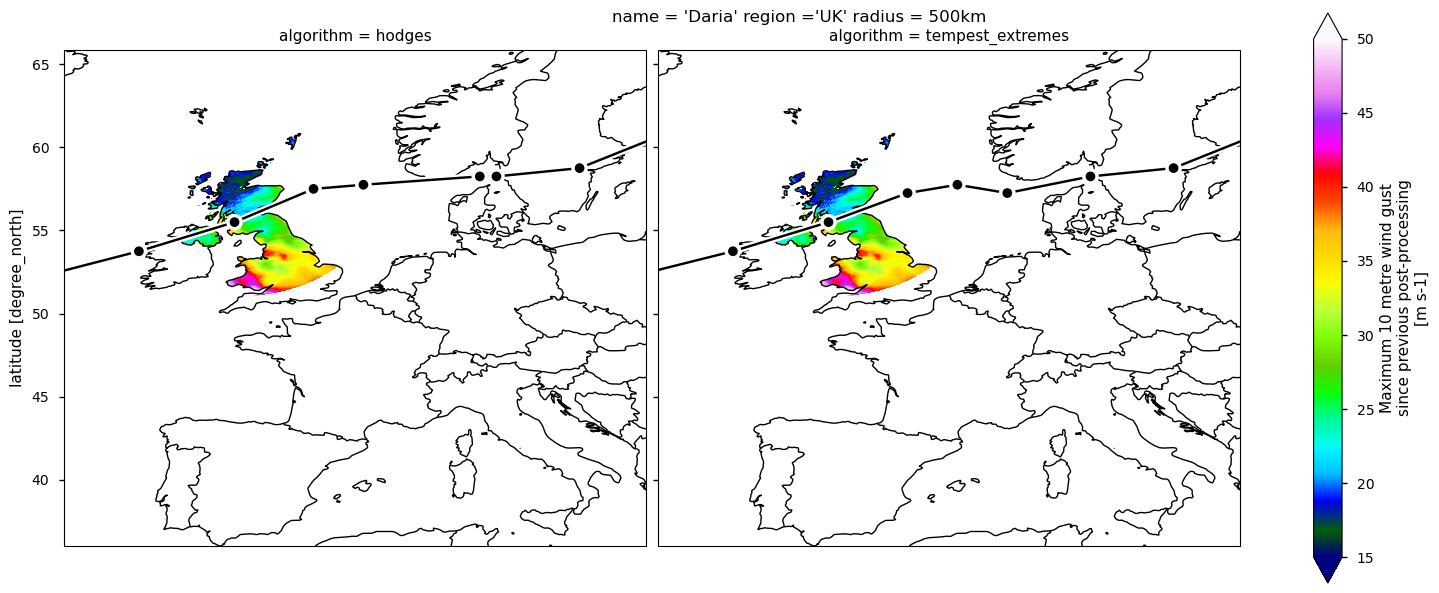

In [20]:
facet = footprints.plot(
    col="algorithm",
    subplot_kws={"projection": projection},
    figsize=small_figsize,
    **footprint_kwargs,
)
for ax, sel in zip(facet.axs.flatten(), facet.name_dicts.flatten()):
    postprocess_ax(ax, tracks[tracks["algorithm"] == sel["algorithm"]], extent)
_ = facet.fig.suptitle(f"{name = } {region =} {radius = }km")

## Step 2: The land-use categories affected

A widespread tool for the spatial and geographical analysis of risks is the land cover categorisation, which allows for the classification of areas for further analysis: areas with an urban land cover are more likely to lead to fatalities when hit by a storm, while areas covered with woodland are more likely to lead to an economic impact on the forestry industry.
To perform a consistent and systematic analysis based on land cover, Copernicus provides a comprehensive, detailed, and harmonised dataset on the land cover and land use of the European continent. The name of the dataset is CORINE and can be downloaded in gridded format on the following portal. For the purpose of the present analysis, the 100m resolution of the dataset was downloaded and coarsened to a 1km resolution to match the resolution of the downscaled windstorm footprint distributed by the EWS. Once coarsened the land cover data has been cropped to keep only the land cover information over the UK and within a 500km radius of the storm track to match the cropped windstorm footprint. The figure below shows the coarsened and cropped land use ready to be matched and analysed with the corresponding footprint.


### Processing

The following functions allow to coarsen the raw Corine dataset and to open it over the region and radius of interest. These two steps allow to match the land use categories with the wind gust speed provided by the cropped footprint.

In [21]:
# Coarsen the Corine land use data set from a 100m x 100m resolution to 1km x 1km
def coarsen_corine(
    corine_path: Path,
    coarsen_corine_path: Path,
) -> xr.DataArray:
    if coarsen_corine_path.exists():
        return xr.open_dataarray(coarsen_corine_path, chunks={})

    print(f"Generating {coarsen_corine_path}")
    da = rxr.open_rasterio(
        corine_path / "DATA" / "U2018_CLC2018_V2020_20u1.tif", chunks="auto"
    )
    da = da.squeeze("band", drop=True).rename("land_use")

    def mode(*args, axis=None, **kwargs):
        return scipy.stats.mode(*args, axis=axis, **kwargs)[0]

    da = da.coarsen({dim: 10 for dim in da.dims}).reduce(mode)
    da.to_netcdf(coarsen_corine_path)
    return coarsen_corine(corine_path, coarsen_corine_path)


# Open the coarsened Corine dataset over an area matching the cropped footprint
def open_corine(
    corine_path: Path,
    coarsen_corine_path: Path,
    track: pd.DataFrame,
    radius: float,
    nuts_region: regionmask.Regions,
    extent: tuple[float, float, float, float],
) -> tuple[pd.DataFrame, xr.DataArray]:
    gdf = gpd.read_file(corine_path / "DATA" / "U2018_CLC2018_V2020_20u1.tif.vat.dbf")
    gdf = gdf.drop(columns=["Count"])
    gdf = gdf[gdf["Value"] < 44]  # Exclude Sea and ocean & NODATA

    da = coarsen_corine(corine_path, coarsen_corine_path)
    transformer = pyproj.Transformer.from_crs(
        "EPSG:4326", da.rio.crs.to_string(), always_xy=True
    )
    distances = []
    for _, node in track.iterrows():
        x, y = transformer.transform(node["longitude"], node["latitude"])
        distance = euclidean_distance(x, y, da["x"], da["y"])
        distances.append(distance)
    distance = xr.concat(distances, "node").min("node")
    da = da.where((distance <= radius * 1.0e3) & (da.isin(gdf["Value"])))
    da = (
        da.rio.reproject("EPSG:4326")
        .drop_vars("spatial_ref")
        .rename(x="longitude", y="latitude")
    )
    da = da.sel(longitude=slice(*extent[:2]), latitude=slice(*extent[-2:][::-1]))

    mask = nuts_region.mask_3D(da, drop=False)
    da = da.where(mask)

    return (gdf, da)

Select the track corresponding to the chosen `algorithm`

In [22]:
track = tracks[tracks["algorithm"] == algorithm]

Opens the Corine land use data with a resolution and area matching the cropped footprint.

In [23]:
corine_gdf, corine_da = open_corine(
    corine_path, coarsen_corine_path, track, radius, nuts_region, extent
)

### Figure 2

Figure 2 shows the land use over the footprint to be analysed and the identified track. The shown land use only covers the regions of interest within the selected radius. To change region or increase / decrease the radius of your analysis got back to `Settings`and set the variables `region`and `radius`.

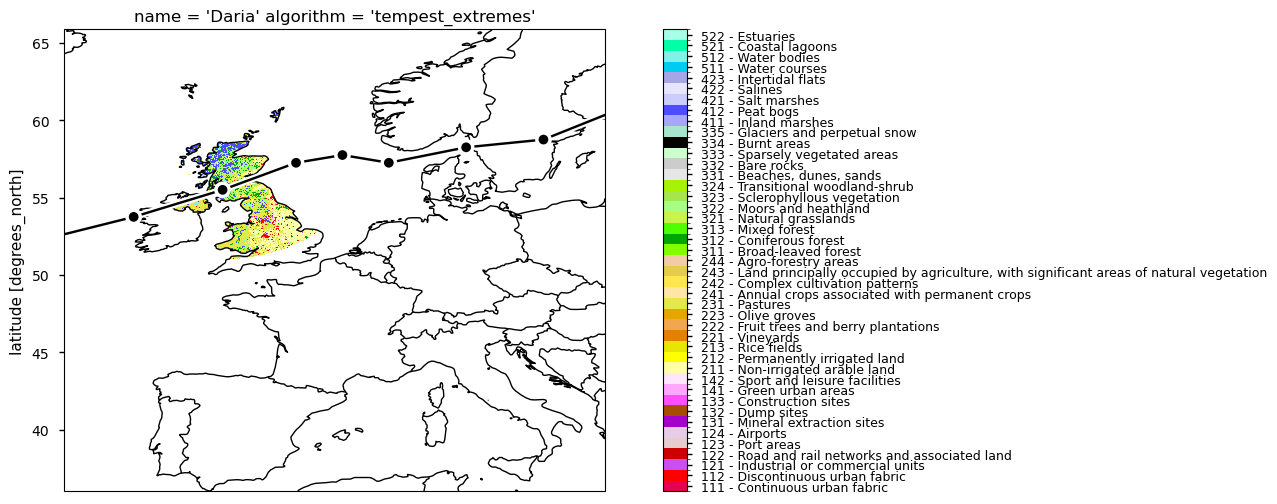

In [24]:
fig, ax = plt.subplots(
    1, 1, subplot_kw={"projection": projection}, figsize=small_figsize
)
im = corine_da.plot(ax=ax, **get_corine_kwargs(corine_gdf))
add_corine_legend(fig, im, corine_gdf)
postprocess_ax(ax, tracks[tracks["algorithm"] == algorithm], extent)
_ = ax.set_title(f"{name = } {algorithm = }")

## Step 3: The land-use-specific Storm Severity Index (SSI)

In this step, we combine the cropped footprint and land use data to quantify and categorise the intensity of the storm on specific land use categories. With the cropped footprint and the matching land cover data at hand, the intensity of the storm of specific land cover categories can be calculated. The intensity over a specific land cover is computed by multiplying the cubed average windstorm speed over the land cover by the total area covered by that same land cover. To compare the land cover categories and find the ones that have been particularly affected by a given storm, a good technique is to create a scatter plot. The scatter plot below plots the land covers considering their area along the horizontal axis and the associated average wind gust speed along the vertical axis. The closer to the top right of the scatter a land cover is, the more severely it has been affected by the selected storm. The further to the right a land cover is,  the higher its area plays a role in the severity, while the higher up a land use is, the higher the wind speed plays a role. To complement the scatter plot, SSI contour lines have been added to define severity categories.





### Processing

In [25]:
# Compute the area of a single sell using latitude weighting.
def compute_cell_area(
    obj: xr.DataArray | xr.Dataset,
    conversion_factor: float = 111,
) -> xr.DataArray:
    resolutions = []
    for coord in ("latitude", "longitude"):
        diff = obj[coord].diff(coord).astype("float32").values
        (resolution,) = set(diff)
        resolutions.append(resolution * conversion_factor)
    weights = np.abs(np.cos(np.deg2rad(obj["latitude"])))
    area = float(abs(math.prod(resolutions))) * weights
    area.attrs = {"long_name": "Area", "units": "km2"}
    return area.rename("area")


# Define the scattered datta to be plotted
def compute_scatter_dataset(footprint, corine_da):
    footprint = footprint.squeeze("region").interp_like(corine_da).expand_dims("region")
    footprint = footprint.assign_coords(area=compute_cell_area(footprint))
    mask = xr.concat(
        [
            (corine_da == value).expand_dims(land_use=[value])
            for value in corine_gdf["Value"]
        ],
        "land_use",
    )
    footprint = footprint.where(mask)
    with xr.set_options(keep_attrs=True):
        wind_gust = footprint.weighted(footprint["area"]).mean(
            ["latitude", "longitude"]
        )
        area = footprint["area"].where(mask).sum(["latitude", "longitude"])
    ssi = area * wind_gust**3
    ssi.attrs = {"long_name": "Mean severity of storms", "units": "1"}
    return xr.merge([wind_gust, area, ssi.rename("ssi")])


# Define the SSI contour lines to be plotted
def compute_ssi_contours(ax, ds_scatter):
    lin_area = xr.DataArray(
        np.linspace(*ax.get_xlim(), 100),
        dims="area",
        attrs=ds_scatter["area"].attrs,
    )
    lin_footprint = xr.DataArray(
        np.linspace(*ax.get_ylim(), 100),
        dims="footprint",
        attrs=ds_scatter["footprint"].attrs,
    )
    return (lin_area * lin_footprint**3).assign_coords(
        area=lin_area, footprint=lin_footprint
    )

In [26]:
ds_scatter = compute_scatter_dataset(footprints.sel(algorithm=algorithm), corine_da)
df_scatter = ds_scatter.to_dataframe()[["footprint", "area", "ssi"]]
df_scatter["label"] = get_corine_labels(corine_gdf)

scatter_values = [
    row["Value"]
    for _, row in corine_gdf.iterrows()
    if int(row["CODE_18"]) in land_use_scatter_codes
]
ds_scatter = ds_scatter.where(ds_scatter["land_use"].isin(scatter_values), drop=True)
df_scatter = df_scatter[
    df_scatter.index.get_level_values("land_use").isin(scatter_values)
]

### Figure 3

Figure 3 shows a scatter plot of all the land uses considering their area along the horizontal axis and the associated average wind speed gust along the vertical axis. The closer to the top right of the scatter a land use is the more severily it has been affected by the selected storm. The further on the right a land use is and the high its area plays a role in the severity, while the higher up a land use is the higher the wind speed played a role.

To complement the scatter plot, SSI contour lines have been added to define severity categories.

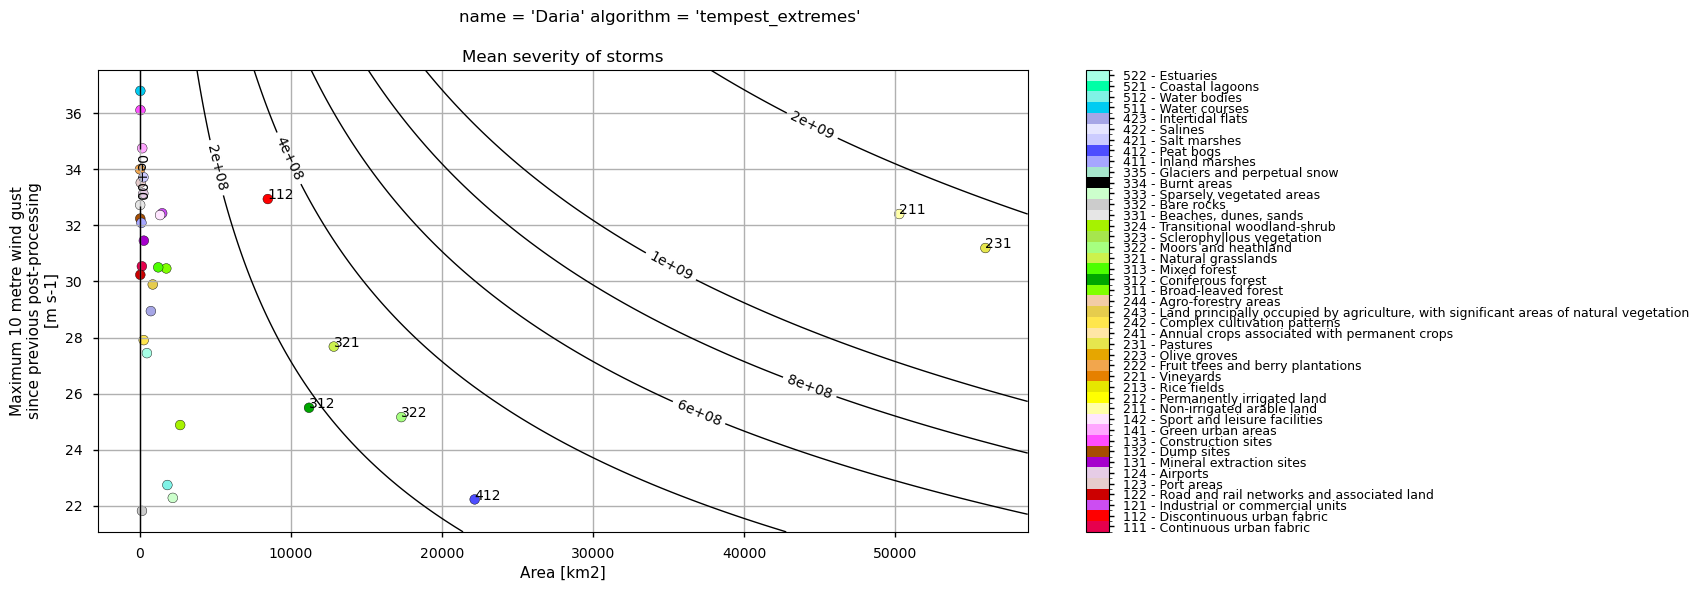

In [27]:
fig, ax = plt.subplots(1, 1, figsize=small_figsize)

axes_kwargs = {"x": "area", "y": "footprint"}
im = ds_scatter.plot.scatter(
    hue="land_use",
    ax=ax,
    **axes_kwargs,
    **get_corine_kwargs(corine_gdf),
    **scatter_kwargs,
)
add_corine_legend(fig, im, corine_gdf)

threshold = 1.0e08
for _, row in df_scatter[df_scatter["ssi"] > threshold].iterrows():
    ax.text(x=row["area"], y=row["footprint"], s=row["label"][:3])


ssi = compute_ssi_contours(ax, ds_scatter)
contour = ssi.plot.contour(
    ax=ax,
    **axes_kwargs,
    **contour_kwargs,
)
plt.clabel(contour, fmt="%1.e")
_ = ax.grid()
ax.set_title(f"{ds_scatter['ssi'].long_name}")
_ = fig.suptitle(f"{name = } {algorithm = }")

### Table 1

For completeness the table below shows the average wind gust speed, area and SSI for each single land use category.

In [28]:
df_scatter.reset_index(drop=True).rename(
    columns={
        "footprint": "Footprint [m s-1]",
        "area": "Area [km2]",
        "ssi": "SSI",
        "label": "Label",
    }
)

,Footprint [m s-1],Area [km2],SSI,Label
0,30.543174,131.374109,3.743280e+06,111 - Continuous urban fabric
1,32.942450,8469.052940,3.027628e+08,112 - Discontinuous urban fabric
2,32.434866,1476.873933,5.039411e+07,121 - Industrial or commercial units
3,30.238679,29.505860,8.158244e+05,122 - Road and rail networks and associated land
4,33.527247,58.841461,2.217569e+06,123 - Port areas
5,33.139819,228.589365,8.319676e+06,124 - Airports
6,31.456635,262.647175,8.175410e+06,131 - Mineral extraction sites
7,32.246345,26.444114,8.866873e+05,132 - Dump sites
8,36.114296,39.226275,1.847628e+06,133 - Construction sites
9,34.755947,156.596238,6.574590e+06,141 - Green urban areas


## Take home messages 📌

This notebook shows how to:

- Identify a specific event within the Enhanced Windstorm Service (EWS) dataset
- Select the footprint over a specific region within a given radius of a storm track
- Identify the land use affected by the storm footprint by using a standard Copernicus land use dataset (CORINE)
- Quantify the intensity of the storm of a single land use category within the selected region and radius.